# Nassau Candy Distributor — Product Line Profitability & Margin Performance Analysis
### Beginner-Friendly Python (pandas) Guide

This guide walks through your exact methodology, step by step. Every line of code is explained — not just *what* it does, but *why* a data analyst would write it and *what business question* it answers.

---

## 0. Setup — Import Libraries & Load the Data

In [22]:
pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [24]:
df = pd.read_csv("Nassau Candy Distributor dataset.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


**Line-by-line explanation:**
- `import pandas as pd` → pandas is the main library for working with tables (rows/columns) in Python. We give it a nickname `pd` so we don't have to type "pandas" every time.
- `import numpy as np` → numpy handles numerical/math operations (like rounding, handling NaN, calculations). Nicknamed `np`.
- `import matplotlib.pyplot as plt` and `import seaborn as sns` → these are for making charts (scatter plots, bar charts) later in the cost diagnostics step.
- `pd.read_csv(...)` → reads your dataset file into a **DataFrame** — think of it as an Excel sheet loaded into Python, stored in the variable `df` (short for "DataFrame").
- `df.head()` → shows the first 5 rows so you can visually confirm the data loaded correctly.

**Business context:** Before analyzing anything, you always want to *see* your raw data first — this is your sanity check that the file loaded properly and columns look as expected.

---

## 1. Data Cleaning & Validation

### 1.1 Inspect structure and data types

In [25]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


- `df.info()` → shows every column name, how many non-missing values it has, and its data type (number, text, date). This is how you spot missing data early.
- `df.describe()` → gives summary statistics (min, max, mean, etc.) for numeric columns like `Sales`, `Cost`, `Gross Profit`, `Units`. This helps you spot suspicious values — e.g., a negative `Sales` or a `Cost` of 0.

**Business context:** You can't trust profitability numbers if the underlying Sales/Cost data has errors. This step is your "data audit."

### 1.2 Validate cost and sales values

In [26]:
# Remove rows where Sales or Cost is negative or missing (data entry errors)
df = df[(df["Sales"] > 0) & (df["Cost"] >= 0)]

- `df["Sales"] > 0` → creates a True/False list: True where Sales is greater than 0.
- `df["Cost"] >= 0` → True where Cost is zero or positive (cost can legitimately be very low, but not negative).
- `&` → means "AND" — both conditions must be True for the row to be kept.
- `df = df[...]` → keeps only the rows that pass both checks, and overwrites `df` with this cleaned version.

**Business context:** A negative Sales value could mean a return/refund got mixed into the order data, or a data entry mistake — either way, it would distort your margin calculations if left in.

### 1.3 Remove zero-sales or invalid profit records

In [27]:
# Remove records with zero sales (no real transaction happened)
df = df[df["Sales"] != 0]

# Remove rows where Gross Profit doesn't logically make sense (Profit shouldn't exceed Sales)
df = df[df["Gross Profit"] <= df["Sales"]]

- `df["Sales"] != 0` → `!=` means "not equal to." This keeps only rows where Sales is NOT zero.
- `df["Gross Profit"] <= df["Sales"]` → Gross Profit = Sales − Cost, so profit should never be *more* than total sales. This line filters out logically impossible rows (a red flag for bad data).

**Business context:** A "sale" with $0 revenue isn't a real business transaction — including it would understate your average order metrics.

### 1.4 Handle missing unit values

In [ ]:
# Check how many units values are missing
print(df["Units"].isnull().sum())

# Fill missing units with the median units value (robust to outliers)
# df["Units"] = df["Units"].fillna(df["Units"].median())

0


- `df["Units"].isnull()` → returns True/False for each row: True if `Units` is missing (NaN).
- `.sum()` → adds up all the Trues (True = 1), giving you a count of missing values.
- `.fillna(...)` → replaces missing values with whatever you put inside the parentheses.
- `df["Units"].median()` → the middle value of all Units — used instead of the *average* because median isn't skewed by extreme outliers (e.g., one bulk order of 10,000 units).

**Business context:** You need Units to calculate "profit per unit" later. Dropping these rows would lose real sales data, so we estimate a reasonable value instead.

### 1.5 Standardize product and division labels

In [46]:
df['Division'].head()

0    Chocolate
1    Chocolate
2    Chocolate
3    Chocolate
4    Chocolate
Name: Division, dtype: str

In [29]:
# Remove extra spaces and make text consistent (Title Case)
df["Division"] = df["Division"].str.strip().str.title()
df["Product Name"] = df["Product Name"].str.strip().str.title()

- `.str.strip()` → removes accidental leading/trailing spaces (e.g., `" Chocolate"` → `"Chocolate"`). Spaces are invisible but make Python treat `"Chocolate"` and `" Chocolate"` as two *different* categories.
- `.str.title()` → converts text to Title Case (e.g., `"CHOCOLATE division"` → `"Chocolate Division"`) so the same category isn't split by inconsistent capitalization.

**Business context:** If "Chocolate" and "chocolate " are treated as two separate divisions due to formatting, your division-level totals in Step 4 will be wrong — silently understating one division and overstating another.

### 1.6 Convert date columns properly

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [31]:
df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,03-01-2024,30-06-2026
1,04-01-2024,01-07-2026
2,04-01-2024,01-07-2026
3,04-01-2024,01-07-2026
4,05-01-2024,05-07-2026


In [32]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y")


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           10194 non-null  int64         
 1   Order ID         10194 non-null  str           
 2   Order Date       10194 non-null  datetime64[us]
 3   Ship Date        10194 non-null  datetime64[us]
 4   Ship Mode        10194 non-null  str           
 5   Customer ID      10194 non-null  int64         
 6   Country/Region   10194 non-null  str           
 7   City             10194 non-null  str           
 8   State/Province   10194 non-null  str           
 9   Postal Code      10194 non-null  str           
 10  Division         10194 non-null  str           
 11  Region           10194 non-null  str           
 12  Product ID       10194 non-null  str           
 13  Product Name     10194 non-null  str           
 14  Sales            10194 non-null  float64       
 

- `pd.to_datetime(...)` → converts a text column (like `"2023-04-01"`) into an actual date type Python understands, so you can later sort, filter, or calculate date differences (e.g., shipping delays) if needed.

---

## 2. Profitability Metric Calculation

Now that the data is clean, we calculate the core metrics **per row (per order line)**.

In [33]:
# Gross Margin % = Gross Profit / Sales, converted to percentage
df["Gross Margin %"] = (df["Gross Profit"] / df["Sales"]) * 100

# Profit per Unit = Gross Profit / Units
df["Profit per Unit"] = df["Gross Profit"] / df["Units"]

# Round for readability
df["Gross Margin %"] = df["Gross Margin %"].round(2)
df["Profit per Unit"] = df["Profit per Unit"].round(2)

In [ ]:
df

- `df["Gross Profit"] / df["Sales"]` → pandas automatically does this division **row by row** across the whole column at once (no loop needed). This is called "vectorized" calculation.
- `* 100` → converts a decimal (0.35) into a percentage (35%).
- `df["New Column"] = ...` → whatever is on the right side gets stored as a brand-new column with that name.
- `.round(2)` → rounds numbers to 2 decimal places so reports look clean (e.g., 34.567891% → 34.57%).

**Business context:**
- **Gross Margin %** tells you *efficiency* — how much of every sales dollar is actually profit, regardless of order size.
- **Profit per Unit** tells you which products make the most money *per item sold* — useful for deciding what to push in promotions or restock priority.

### Total profit contribution (per product)

In [34]:
# Total profit contribution by product — group all rows by product, then sum profit
product_profit = df.groupby("Product Name")["Gross Profit"].sum().reset_index()
product_profit = product_profit.rename(columns={"Gross Profit": "Total Profit Contribution"})
product_profit = product_profit.sort_values("Total Profit Contribution", ascending=False)
product_profit.head(10)

,Product Name,Total Profit Contribution
13,Wonka Bar -Scrumdiddlyumptious,19357.50
12,Wonka Bar - Triple Dazzle Caramel,18610.20
10,Wonka Bar - Milk Chocolate,17443.37
11,Wonka Bar - Nutty Crunch Surprise,16819.95
9,Wonka Bar - Fudge Mallows,16593.60
6,Lickable Wallpaper,3930.00
14,Wonka Gum,310.70
0,Everlasting Gobstopper,104.00
4,Kazookles,92.75
3,Hair Toffee,59.50


- `df.groupby("Product Name")` → collapses the data so all rows belonging to the same product are bundled together.
- `["Gross Profit"].sum()` → within each product bundle, adds up all the Gross Profit values → gives one total profit number per product.
- `.reset_index()` → turns the grouped result back into a normal, clean table (otherwise "Product Name" becomes a special index instead of a regular column).
- `.rename(columns={...})` → renames the "Gross Profit" column to something clearer for this new summarized table.
- `.sort_values(..., ascending=False)` → sorts from highest to lowest profit (`ascending=False` means "biggest first").
- `.head(10)` → shows just the top 10 rows so you can quickly see your best-performing products.

**Business context:** This answers "which products actually make Nassau Candy the most money in total?" — not just per-unit, but overall business impact.

---

## 3. Product-Level Profitability Analysis

### 3.1 Rank products by Gross Profit and Gross Margin

In [35]:
product_summary = df.groupby("Product Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Gross Profit", "sum"),
    Total_Units=("Units", "sum"),
    Avg_Margin_Percent=("Gross Margin %", "mean")
).reset_index()

product_summary["Avg_Margin_Percent"] = product_summary["Avg_Margin_Percent"].round(2)

# Rank by profit
product_summary["Profit_Rank"] = product_summary["Total_Profit"].rank(ascending=False)

# Rank by margin
product_summary["Margin_Rank"] = product_summary["Avg_Margin_Percent"].rank(ascending=False)

product_summary.sort_values("Profit_Rank").head(10)

,Product Name,Total_Sales,Total_Profit,Total_Units,Avg_Margin_Percent,Profit_Rank,Margin_Rank
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.44,1.0,4.0
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.33,2.0,6.0
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.92,3.0,7.0
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.35,4.0,3.0
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.67,5.0,5.0
6,Lickable Wallpaper,7860.00,3930.00,393,50.00,6.0,11.0
14,Wonka Gum,597.50,310.70,478,52.00,7.0,10.0
0,Everlasting Gobstopper,130.00,104.00,13,80.00,8.0,1.0
4,Kazookles,1205.75,92.75,371,7.69,9.0,15.0
3,Hair Toffee,76.50,59.50,17,77.78,10.0,2.0


- `.agg(...)` → lets you calculate **multiple** summary statistics at once for each product group. Inside, each line follows the pattern `New_Column_Name = ("Source Column", "calculation")`.
  - `("Sales", "sum")` → add up total sales per product.
  - `("Gross Profit", "sum")` → add up total profit per product.
  - `("Units", "sum")` → add up total units sold per product.
  - `("Gross Margin %", "mean")` → average margin percentage per product (`mean` = average).
- `.rank(ascending=False)` → assigns rank 1 to the highest value, rank 2 to the next highest, etc. `ascending=False` means highest = best rank.

**Business context:** This single table becomes your master reference — "who are my biggest profit generators, and who has the best margins" — often these are *not* the same products.

### 3.2 Identify high-profit/high-margin, high-sales/low-margin, and low-sales/low-profit products

In [36]:
# Set thresholds using the median as a practical cutoff
sales_median = product_summary["Total_Sales"].median()
margin_median = product_summary["Avg_Margin_Percent"].median()
profit_median = product_summary["Total_Profit"].median()

# High-profit / High-margin: "Star" products
stars = product_summary[
    (product_summary["Total_Profit"] > profit_median) &
    (product_summary["Avg_Margin_Percent"] > margin_median)
]

# High-sales / Low-margin: "Volume traps" — sell a lot, but barely profitable
volume_traps = product_summary[
    (product_summary["Total_Sales"] > sales_median) &
    (product_summary["Avg_Margin_Percent"] < margin_median)
]

# Low-sales / Low-profit: "Underperformers"
underperformers = product_summary[
    (product_summary["Total_Sales"] < sales_median) &
    (product_summary["Total_Profit"] < profit_median)
]

print("Star products:", len(stars))
print("Volume traps:", len(volume_traps))
print("Underperformers:", len(underperformers))

Star products: 5
Volume traps: 2
Underperformers: 6


- `.median()` → the "middle" value of a column, used here as a simple, fair cutoff point that automatically adjusts to your dataset (instead of guessing a hardcoded number).
- Each block uses `&` (AND) inside `df[ (condition1) & (condition2) ]` to filter products meeting **both** conditions simultaneously.
- `len(...)` → counts how many rows (products) fall into each category.

**Business context:** This is the heart of product strategy:
- **Stars** → protect and promote these; they're your best combination of scale and efficiency.
- **Volume traps** → high revenue can look impressive on a sales report, but if margin is thin, growing this product further barely helps profit — a repricing or cost review candidate.
- **Underperformers** → candidates for discontinuation or a complete relaunch (packaging, pricing, positioning).

---

## 4. Division-Level Performance Analysis

In [37]:
division_summary = df.groupby("Division").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Gross Profit", "sum"),
    Avg_Margin_Percent=("Gross Margin %", "mean")
).reset_index()

division_summary["Avg_Margin_Percent"] = division_summary["Avg_Margin_Percent"].round(2)

# Revenue vs Profit imbalance: what % of total company revenue and profit does each division represent?
division_summary["Revenue_Share_%"] = (division_summary["Total_Sales"] / division_summary["Total_Sales"].sum() * 100).round(2)
division_summary["Profit_Share_%"] = (division_summary["Total_Profit"] / division_summary["Total_Profit"].sum() * 100).round(2)

division_summary.sort_values("Total_Profit", ascending=False)

,Division,Total_Sales,Total_Profit,Avg_Margin_Percent,Revenue_Share_%,Profit_Share_%
0,Chocolate,131692.90,88824.62,67.46,92.88,95.06
1,Other,9663.25,4333.45,37.67,6.82,4.64
2,Sugar,427.48,284.73,57.69,0.30,0.30


- Same `.groupby().agg()` pattern as before, but now grouping by `Division` instead of `Product Name`.
- `division_summary["Total_Sales"].sum()` → total sales across *all* divisions combined (the grand total).
- Dividing each division's sales by that grand total, then `* 100`, gives you what % share of total company revenue that division represents. Same logic for profit share.

**Business context:** A healthy division has similar Revenue Share % and Profit Share %. If a division has 30% of revenue but only 10% of profit, it's dragging down company-wide margin — a **structural margin issue**.

### Flagging divisions with margin issues

In [38]:
company_avg_margin = df["Gross Margin %"].mean()

division_summary["Performance_Flag"] = np.where(
    division_summary["Avg_Margin_Percent"] >= company_avg_margin,
    "Strong Efficiency",
    "Structural Margin Issue"
)

division_summary

,Division,Total_Sales,Total_Profit,Avg_Margin_Percent,Revenue_Share_%,Profit_Share_%,Performance_Flag
0,Chocolate,131692.90,88824.62,67.46,92.88,95.06,Strong Efficiency
1,Other,9663.25,4333.45,37.67,6.82,4.64,Structural Margin Issue
2,Sugar,427.48,284.73,57.69,0.30,0.30,Structural Margin Issue


- `df["Gross Margin %"].mean()` → the average margin across the *entire company* (all rows), used as a benchmark.
- `np.where(condition, value_if_true, value_if_false)` → this is like an IF formula in Excel: for each division, check the condition, and label it accordingly.

**Business context:** Instantly flags which divisions perform above or below the company average — a quick executive-summary style output.

---

## 5. Profit Concentration (Pareto) Analysis

The Pareto principle asks: *do a small number of products drive most of the revenue/profit?* (the "80/20 rule")

In [39]:
# Sort products by profit, descending
pareto = product_summary.sort_values("Total_Profit", ascending=False).reset_index(drop=True)

# Cumulative profit and cumulative % of total profit
pareto["Cumulative_Profit"] = pareto["Total_Profit"].cumsum()
pareto["Cumulative_Profit_%"] = (pareto["Cumulative_Profit"] / pareto["Total_Profit"].sum() * 100).round(2)

# What % of PRODUCTS does this represent?
pareto["Product_Rank_%"] = ((pareto.index + 1) / len(pareto) * 100).round(2)

# Find how many products it takes to reach 80% of total profit
products_for_80pct = pareto[pareto["Cumulative_Profit_%"] <= 80].shape[0]
print(f"{products_for_80pct} products generate 80% of total profit, "
      f"out of {len(pareto)} total products "
      f"({round(products_for_80pct/len(pareto)*100,1)}% of the product line).")

4 products generate 80% of total profit, out of 15 total products (26.7% of the product line).


- `.cumsum()` → "cumulative sum": running total as you go down the sorted list (row 1 profit, row 1+2, row 1+2+3, etc.).
- Dividing cumulative profit by total profit `* 100` → converts the running total into a running **percentage** of all profit.
- `pareto.index + 1` → row position (starting at 1 instead of 0) — used to calculate what % of products we're up to.
- `pareto[pareto["Cumulative_Profit_%"] <= 80]` → filters to only the top-ranked products whose *cumulative* profit is still under 80%.
- `.shape[0]` → counts how many rows are in that filtered result = how many products it took to hit 80%.

**Business context:** This is the single most powerful insight for leadership — e.g., "12% of our SKUs generate 80% of our profit." It tells you exactly where to focus retention, marketing, and inventory investment — and where you're carrying dead weight.

### Repeat the same logic for Revenue concentration

In [40]:
pareto_sales = product_summary.sort_values("Total_Sales", ascending=False).reset_index(drop=True)
pareto_sales["Cumulative_Sales_%"] = (pareto_sales["Total_Sales"].cumsum() / pareto_sales["Total_Sales"].sum() * 100).round(2)

products_for_80pct_sales = pareto_sales[pareto_sales["Cumulative_Sales_%"] <= 80].shape[0]
print(f"{products_for_80pct_sales} products generate 80% of total revenue.")

4 products generate 80% of total revenue.


Same logic as above, just applied to `Total_Sales` instead of `Total_Profit`.

### Detect over-dependency by State/Region

In [41]:
region_concentration = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Gross Profit", "sum")
).reset_index().sort_values("Total_Sales", ascending=False)

region_concentration["Sales_Share_%"] = (region_concentration["Total_Sales"] / region_concentration["Total_Sales"].sum() * 100).round(2)

region_concentration

,Region,Total_Sales,Total_Profit,Sales_Share_%
3,Pacific,46301.53,30485.94,32.66
0,Atlantic,41197.24,26973.70,29.06
2,Interior,32037.60,21282.49,22.60
1,Gulf,22247.26,14700.67,15.69


**Business context:** If one region drives, say, 60% of revenue, that's an **over-dependency risk** — a local economic downturn, competitor entry, or logistics disruption in that single region could seriously hurt the whole business.

---

## 6. Cost Structure Diagnostics

### 6.1 Cost vs Sales scatter plot

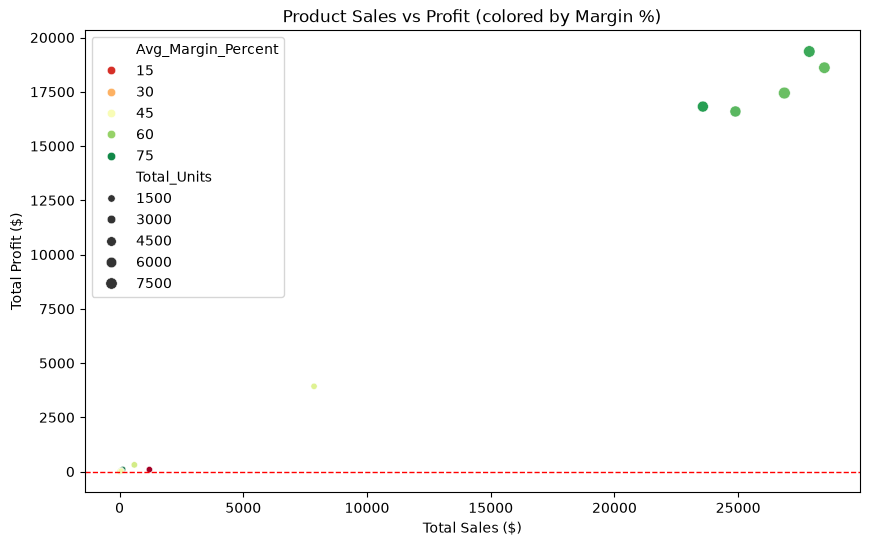

In [45]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=product_summary, x="Total_Sales", y="Total_Profit", hue="Avg_Margin_Percent", palette="RdYlGn", size="Total_Units" if "Total_Units" in product_summary.columns else None)
plt.title("Product Sales vs Profit (colored by Margin %)")
plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
# Save the figure in HD
plt.savefig("sales_vs_profit.png", dpi=300, bbox_inches="tight")
plt.show()

- `plt.figure(figsize=(10,6))` → sets the chart size (width, height) in inches so it's readable.
- `sns.scatterplot(...)` → plots one dot per product: x-axis = Sales, y-axis = Profit.
  - `hue="Avg_Margin_Percent"` → colors each dot based on margin (e.g., red = low margin, green = high margin) using `palette="RdYlGn"` (Red-Yellow-Green).
- `plt.axhline(0, ...)` → draws a horizontal red dashed line at Profit = 0, so you can instantly spot any product with *negative* profit (a loss-maker).
- `plt.title/xlabel/ylabel` → chart labels for readability.
- `plt.show()` → renders the chart.

**Business context:** Products in the bottom-right (high sales, low/negative profit, red color) are your **cost-heavy, margin-poor products** — exactly what this diagnostic step is designed to catch visually.

### 6.2 Flag products needing repricing, cost renegotiation, or discontinuation

In [43]:
def flag_action(row):
    if row["Total_Profit"] < 0:
        return "Discontinuation Review"
    elif row["Avg_Margin_Percent"] < margin_median and row["Total_Sales"] > sales_median:
        return "Repricing Candidate"
    elif row["Avg_Margin_Percent"] < margin_median:
        return "Cost Renegotiation"
    else:
        return "Healthy"

product_summary["Action_Flag"] = product_summary.apply(flag_action, axis=1)

product_summary["Action_Flag"].value_counts()

Action_Flag
Healthy                8
Cost Renegotiation     5
Repricing Candidate    2
Name: count, dtype: int64

- `def flag_action(row):` → defines a custom function. `row` represents one product's data at a time.
- Inside, it's a simple decision tree (like nested IF statements in Excel):
  - Negative total profit → **Discontinuation Review** (actively losing money).
  - Below-median margin but above-median sales → **Repricing Candidate** (sells well, but priced too low relative to cost — a volume trap).
  - Below-median margin generally → **Cost Renegotiation** (the cost side needs attention, e.g., supplier costs).
  - Otherwise → **Healthy**.
- `product_summary.apply(flag_action, axis=1)` → runs this function on **every row** (`axis=1` means "go row by row," not column by column), and stores the result in a new column.
- `.value_counts()` → counts how many products fall into each flag category — a quick summary for a report or dashboard.

**Business context:** This turns your entire analysis into a **clear action list** for management: which products need a price increase, which need supplier renegotiation, and which should be phased out — the practical output of the whole project.

---

## 7. Export Your Results

In [44]:
# Save your key summary tables for your report/dashboard
product_summary.to_csv("product_profitability_summary.csv", index=False)
division_summary.to_csv("division_performance_summary.csv", index=False)
pareto.to_csv("pareto_profit_analysis.csv", index=False)

In [ ]:
pareto

- `.to_csv("filename.csv", index=False)` → saves the DataFrame as a CSV file. `index=False` prevents pandas from adding an extra unnamed column with row numbers — keeping the file clean for Excel/Power BI/Tableau import.

**Business context:** These exported files become the data source for your final dashboard or slide deck — the deliverable stakeholders will actually see.

---

## Quick Recap: Business Questions Answered by Each Section

| Section | Business Question |
|---|---|
| 1. Cleaning | Can I trust this data? |
| 2. Metrics | How profitable is each order/product, per dollar and per unit? |
| 3. Product Analysis | Which products should I invest in vs. fix vs. cut? |
| 4. Division Analysis | Which business divisions are efficient vs. structurally weak? |
| 5. Pareto Analysis | How concentrated is my profit — and where's my risk exposure? |
| 6. Cost Diagnostics | Which specific products need repricing, cost renegotiation, or discontinuation? |